# DEEPP Milestone 2 : Data Cleaning & EDA
**Banking Credit Risk & Transaction Behavior Analysis** · Czech Financial Dataset (Berka) · 1993–1998

**Business question:** which customer, account and transaction characteristics are associated with problematic loans (status B and D)?
**KPI:** Problematic Loan Rate = (B + D) ÷ total loans. Milestone 1 target: from 11% to below 5%.

**Structure:** Step 1 understand → Step 2 clean → Step 3 EDA → Step 4 insights → Step 5 business alignment.

In [1]:
!pip install duckdb "kagglehub[pandas-datasets]" -q

In [2]:
import warnings, duckdb, kagglehub
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from kagglehub import KaggleDatasetAdapter

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

TABLES = ['account', 'card', 'client', 'disp', 'district', 'loan', 'order', 'trans']
raw = {t: kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS,
                                 'marceloventura/the-berka-dataset', f'{t}.csv',
                                 pandas_kwargs={'sep': ';', 'low_memory': False})
       for t in TABLES}

account, card, client, disp = raw['account'], raw['card'], raw['client'], raw['disp']
district, loan, order, trans = raw['district'], raw['loan'], raw['order'], raw['trans']

print({t: df.shape for t, df in raw.items()})

100%|██████████| 152k/152k [00:00<00:00, 1.11MB/s]


Using Colab cache for faster access to the 'the-berka-dataset' dataset.
Using Colab cache for faster access to the 'the-berka-dataset' dataset.
Using Colab cache for faster access to the 'the-berka-dataset' dataset.
Using Colab cache for faster access to the 'the-berka-dataset' dataset.
Using Colab cache for faster access to the 'the-berka-dataset' dataset.
Using Colab cache for faster access to the 'the-berka-dataset' dataset.
Using Colab cache for faster access to the 'the-berka-dataset' dataset.
{'account': (4500, 4), 'card': (892, 4), 'client': (5369, 3), 'disp': (5369, 4), 'district': (77, 16), 'loan': (682, 7), 'order': (6471, 6), 'trans': (1056320, 10)}


> Kaggle login: in Colab add `KAGGLE_USERNAME` and `KAGGLE_KEY` in the Secrets panel. Offline fallback: upload the 8 CSVs and use `raw = {t: pd.read_csv(f'{t}.csv', sep=';') for t in TABLES}`. Everything below reads from `raw`.

---
## Step 1 — Understand the dataset

In [3]:
PK = {'account': 'account_id', 'card': 'card_id', 'client': 'client_id', 'disp': 'disp_id',
      'district': 'A1', 'loan': 'loan_id', 'order': 'order_id', 'trans': 'trans_id'}

for t, k in PK.items():
    print(f'{t:9s} {len(raw[t]):>9,} rows | unique PK: {len(raw[t]) == raw[t][k].nunique()} | missing cells: {raw[t].isna().sum().sum():>7,}')

FK = [('loan','account_id','account','account_id'), ('trans','account_id','account','account_id'),
      ('order','account_id','account','account_id'), ('disp','account_id','account','account_id'),
      ('disp','client_id','client','client_id'),     ('card','disp_id','disp','disp_id'),
      ('account','district_id','district','A1'),     ('client','district_id','district','A1')]
orphans = {f'{c}.{ck}': int((~raw[c][ck].isin(raw[p][pk])).sum()) for c, ck, p, pk in FK}
print('\nOrphan rows per foreign key:', orphans)

print('\nLoan status:', loan['status'].value_counts().to_dict())
print('Accounts:', account['account_id'].nunique(), '| accounts with a loan:', loan['account_id'].nunique())
print('Accounts with more than one loan:', (loan.groupby('account_id').size() > 1).sum())
print('Disposition types:', disp['type'].value_counts().to_dict())

account       4,500 rows | unique PK: True | missing cells:       0
card            892 rows | unique PK: True | missing cells:       0
client        5,369 rows | unique PK: True | missing cells:       0
disp          5,369 rows | unique PK: True | missing cells:       0
district         77 rows | unique PK: True | missing cells:       0
loan            682 rows | unique PK: True | missing cells:       0
order         6,471 rows | unique PK: True | missing cells:       0
trans     1,056,320 rows | unique PK: True | missing cells: 2,208,738

Orphan rows per foreign key: {'loan.account_id': 0, 'trans.account_id': 0, 'order.account_id': 0, 'disp.account_id': 0, 'disp.client_id': 0, 'card.disp_id': 0, 'account.district_id': 0, 'client.district_id': 0}

Loan status: {'C': 403, 'A': 203, 'D': 45, 'B': 31}
Accounts: 4500 | accounts with a loan: 682
Accounts with more than one loan: 0
Disposition types: {'OWNER': 4500, 'DISPONENT': 869}


### How the tables connect

| Table | 1 row = | Key | Role here |
|---|---|---|---|
| `client` | a customer | PK client_id, FK district_id | demographics |
| `account` | an account | PK account_id, FK district_id | opening date, statement frequency |
| `disp` | a right of access | PK disp_id, FK client_id + account_id | **bridge** between client and account |
| `trans` | a transaction | PK trans_id, FK account_id | behaviour: balance, cash in and out |
| `loan` | a loan | PK loan_id, FK account_id | **target**: amount, duration, status |
| `order` | a standing order | PK order_id, FK account_id | committed recurring outflow |
| `card` | a card | PK card_id, FK disp_id | card tier |
| `district` | a district | PK A1 | salary, unemployment |

**Reading the output.** Every PK is unique and no FK is orphaned, so the tables join cleanly. Three consequences:

1. `account_id` is the spine, so transaction behaviour reaches a loan without passing through the customer.
2. `disp` is the only client to account link. It has 5,369 rows for 4,500 accounts, so joining without filtering to `OWNER` would multiply the 682 loans.
3. Only 682 of 4,500 accounts ever borrowed. The analysis unit is **682 loans**.

`status` mixes finished (A, B) vs running (C, D) with healthy (A, C) vs problematic (B, D), so the KPI is (B + D) ÷ total, not a default rate.

---
## Step 2 — Data cleaning

### 2.1 Data types and hidden variables

In [4]:
to_date = lambda s: pd.to_datetime('19' + s.astype(str).str.zfill(6), format='%Y%m%d')

for df in (account, loan, trans):
    df['date'] = to_date(df['date'])
card['issued'] = pd.to_datetime('19' + card['issued'].str[:6], format='%Y%m%d')

bn = client['birth_number'].astype(str).str.zfill(6)
mm = bn.str[2:4].astype(int)
client['gender'] = np.where(mm > 50, 'female', 'male')
client['birth_date'] = pd.to_datetime('19' + bn.str[:2] + (mm - np.where(mm > 50, 50, 0)).astype(str).str.zfill(2) + bn.str[4:],
                                      format='%Y%m%d')

district.columns = ['district_id','district_name','region','n_inhabitants','n_mun_lt499','n_mun_500_1999',
                    'n_mun_2000_9999','n_mun_gt10000','n_cities','ratio_urban','avg_salary','unemp_95',
                    'unemp_96','entrep_per_1000','crime_95','crime_96']
for c in ['unemp_95', 'crime_95']:
    district[c] = pd.to_numeric(district[c], errors='coerce')
district['unemp_95'] = district['unemp_95'].fillna(district['unemp_96'])
district['crime_95'] = district['crime_95'].fillna(district['crime_96'])

print('Loan date range:', loan['date'].min().date(), 'to', loan['date'].max().date())
print('Birth years:', client['birth_date'].dt.year.min(), 'to', client['birth_date'].dt.year.max(),
      '| gender:', client['gender'].value_counts().to_dict())

Loan date range: 1993-07-05 to 1998-12-08
Birth years: 1911 to 1987 | gender: {'male': 2724, 'female': 2645}


**Issue.** Dates are `YYMMDD` integers, `birth_number` hides gender and birth date, district columns are unnamed `A1`–`A16` with a `?` in two of them.

**Decision.** Century forced to `19` when parsing (otherwise `11` reads as 2011 and ages go negative), gender decoded by the Czech rule of +50 on the month for women, district columns renamed, `?` filled from the same district's 1996 value. The output confirms real `datetime` columns and named districts.

### 2.2 Category codes and missing values

In [5]:
trans['k_symbol'] = trans['k_symbol'].replace(' ', np.nan)   # blank string = hidden missing value
order['k_symbol'] = order['k_symbol'].replace(' ', np.nan)

trans['type_en'] = trans['type'].map({'PRIJEM': 'credit', 'VYDAJ': 'withdrawal', 'VYBER': 'withdrawal_cash'})
account['frequency_en'] = account['frequency'].map({'POPLATEK MESICNE': 'monthly', 'POPLATEK TYDNE': 'weekly',
                                                    'POPLATEK PO OBRATU': 'after_transaction'})
loan['is_problem'] = loan['status'].isin(['B', 'D']).astype(int)

miss = trans.isna().sum()
print('Missing in trans:')
print((miss[miss > 0] / len(trans) * 100).round(1).astype(str) + '%')
print('\nMissing in other tables:', {t: int(raw[t].isna().sum().sum()) for t in TABLES if t != 'trans'})

Missing in trans:
operation    17.3%
k_symbol     50.7%
bank         74.1%
account      72.0%
dtype: object

Missing in other tables: {'account': 0, 'card': 0, 'client': 0, 'disp': 0, 'district': 0, 'loan': 0, 'order': 1379}


**Output.** Four `trans` columns are incomplete (`bank` 74%, `account` 72%, `k_symbol` 51%, `operation` 17%), and `k_symbol` hid 53,433 blanks that pandas counted as filled. No other table has missing data.

**Decision.** Nothing imputed, nothing dropped. The blanks are structural, since a cash deposit has no counterparty bank, and the columns used downstream (`amount`, `balance`, `date`, `type`) are fully populated.

### 2.3 Duplicates and outliers

Full-row duplicates: {'account': 0, 'card': 0, 'client': 0, 'disp': 0, 'district': 0, 'loan': 0, 'order': 0, 'trans': 0}
transaction amount   upper fence=     16,796  outliers= 120,215 (11.38%)  max=87,400
account balance      upper fence=     90,405  outliers=  34,806 ( 3.30%)  max=209,637
loan amount          upper fence=    426,537  outliers=      18 ( 2.64%)  max=590,820
monthly payment      upper fence=     10,818  outliers=       0 ( 0.00%)  max=9,910

Negative balances: 2999 transactions in 288 accounts


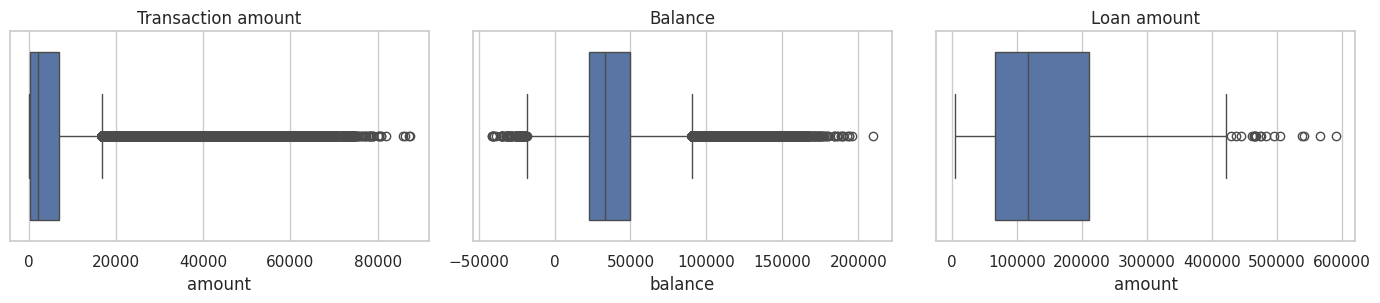

In [6]:
print('Full-row duplicates:', {t: int(raw[t].duplicated().sum()) for t in TABLES})

def iqr_report(s, name):
    q1, q3 = s.quantile([.25, .75]); hi = q3 + 1.5 * (q3 - q1)
    out = ((s < q1 - 1.5 * (q3 - q1)) | (s > hi)).sum()
    print(f'{name:20s} upper fence={hi:>11,.0f}  outliers={out:>8,} ({100*out/len(s):5.2f}%)  max={s.max():,.0f}')

iqr_report(trans['amount'], 'transaction amount'); iqr_report(trans['balance'], 'account balance')
iqr_report(loan['amount'], 'loan amount');         iqr_report(loan['payments'], 'monthly payment')

print('\nNegative balances:', (trans['balance'] < 0).sum(), 'transactions in',
      trans.loc[trans['balance'] < 0, 'account_id'].nunique(), 'accounts')

fig, ax = plt.subplots(1, 3, figsize=(14, 3.2))
for a, (s, t) in zip(ax, [(trans['amount'], 'Transaction amount'), (trans['balance'], 'Balance'), (loan['amount'], 'Loan amount')]):
    sns.boxplot(x=s, ax=a); a.set_title(t)
plt.tight_layout(); plt.show()

**Output.** Zero duplicate rows in all eight tables. IQR flags about 120,000 transaction amounts and 18 loan amounts, and 2,999 transactions sit at a negative balance.

**Decision.** No rows removed. The distributions are right skewed by nature, and 18 of 682 loans is 2.6% of the target. Negative balances become a **feature** instead, since they are the clearest distress signal here. The real duplication risk is in the joins, so `disp` is filtered to `OWNER` and the loan count asserted at 682.

### 2.4 Build the analysis table

One row per loan. Two rules: `disp` filtered to `OWNER`, and transaction aggregates use **only transactions dated before the loan date** so the outcome cannot leak into the predictors.

In [7]:
master = duckdb.connect().execute('''
WITH owner_disp AS (SELECT account_id, client_id FROM disp WHERE type = 'OWNER'),
pre_trx AS (SELECT t.* FROM trans t JOIN loan l USING(account_id) WHERE t.date < l.date),
trx_agg AS (
  SELECT account_id,
         COUNT(*) AS n_trx, AVG(balance) AS avg_balance, MIN(balance) AS min_balance,
         SUM(CASE WHEN balance < 0 THEN 1 ELSE 0 END) AS n_negative_balance,
         SUM(CASE WHEN type_en = 'credit' THEN amount END)  AS total_credit,
         SUM(CASE WHEN type_en <> 'credit' THEN amount END) AS total_withdrawal,
         DATEDIFF('day', MIN(date), MAX(date)) AS trx_history_days
  FROM pre_trx GROUP BY account_id)
SELECT l.loan_id, l.account_id, l.date AS loan_date, l.amount AS loan_amount, l.duration,
       l.payments, l.status, l.is_problem,
       a.date AS account_open_date, a.frequency_en,
       c.gender, c.birth_date,
       d.district_name, d.avg_salary, d.unemp_96,
       g.n_trx, g.avg_balance, g.min_balance, g.n_negative_balance,
       g.total_credit, g.total_withdrawal, g.trx_history_days
FROM loan l
JOIN account a USING(account_id)
JOIN owner_disp od USING(account_id)
JOIN client c ON c.client_id = od.client_id
LEFT JOIN district d ON d.district_id = a.district_id
LEFT JOIN trx_agg g ON g.account_id = l.account_id
''').df()

assert len(master) == len(loan), 'join multiplied the loans'

monthly_inflow = master['total_credit'] / (master['trx_history_days'] / 30.44)
master['age_at_loan']       = ((master['loan_date'] - master['birth_date']).dt.days / 365.25).round(1)
master['tenure_days']       = (master['loan_date'] - master['account_open_date']).dt.days
master['payment_to_income'] = master['payments'] / master['avg_salary']
master['payment_to_inflow'] = master['payments'] / monthly_inflow
master['outflow_to_inflow'] = master['total_withdrawal'] / master['total_credit']
master['ever_negative']     = (master['n_negative_balance'].fillna(0) > 0).astype(int)
master['loan_year']         = master['loan_date'].dt.year

print(master.shape, '| Problematic Loan Rate:', f"{master['is_problem'].mean():.1%}",
      f"({master['is_problem'].sum()} of {len(master)})")

(682, 29) | Problematic Loan Rate: 11.1% (76 of 682)


The derived features are the Milestone 1 hypotheses turned into columns: weak liquidity → `avg_balance`, `min_balance`, `ever_negative`; cash flow strain → `outflow_to_inflow`; loan burden → `payment_to_inflow`, `payment_to_income`, `loan_amount`; thin history → `tenure_days`, `n_trx`.

---
## Step 3 — Exploratory data analysis

The five sections below run in a fixed order. 3.1 sets the baseline KPI, then 3.2 to 3.5 test the four Milestone 1 root causes one at a time, from loan terms to account behaviour to customer profile. Each section keeps the same internal order: **focus → variables → method → output → insight**, and closes by handing over to the next section.

In [8]:
BASE = master['is_problem'].mean() * 100

def rate_by(col, data=None):
    d = master if data is None else data
    out = d.groupby(col, observed=True)['is_problem'].agg(loans='size', problems='sum', rate='mean')
    out['rate'] = (out['rate'] * 100).round(1)
    return out

def plot_rate(col, ax, title, colors=None):
    r = rate_by(col)
    sns.barplot(x=r.index.astype(str), y=r['rate'], ax=ax, palette=colors)
    ax.axhline(BASE, ls='--', color='grey'); ax.set_title(title, fontsize=11); ax.set_ylabel('% problematic'); ax.set_xlabel('')
    return r

for c, lbl in [('payment_to_income', 'pti_q'), ('payment_to_inflow', 'ptif_q'),
               ('outflow_to_inflow', 'oti_q'), ('loan_amount', 'amount_q'),
               ('avg_balance', 'balance_q'), ('tenure_days', 'tenure_q')]:
    master[lbl] = pd.qcut(master[c], 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

print(f'Baseline problematic loan rate: {BASE:.1f}%')

Baseline problematic loan rate: 11.1%


### 3.1 Baseline KPI and its stability over time
Focus: fix the reference level before anything is compared against it.
Variables: `status`, `loan_year`. Method: distribution and trend.

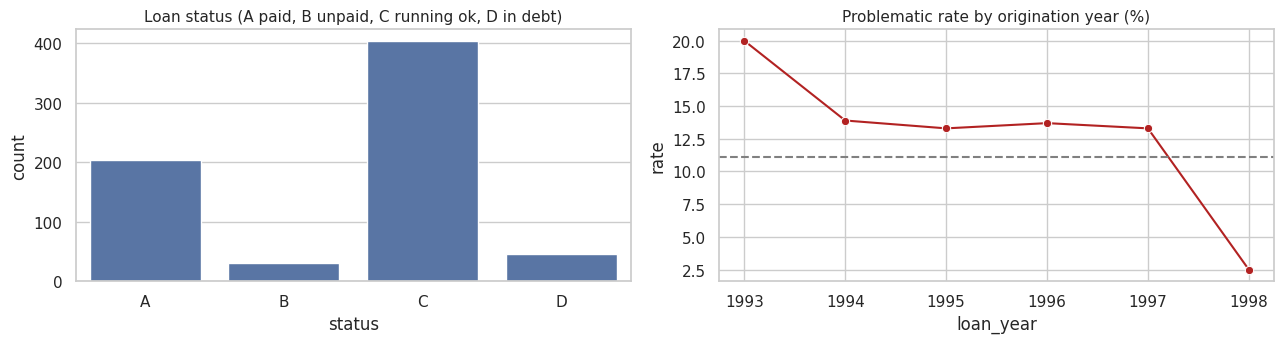

           loans  problems  rate
loan_year                       
1993          20         4  20.0
1994         101        14  13.9
1995          90        12  13.3
1996         117        16  13.7
1997         196        26  13.3
1998         158         4   2.5


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
sns.countplot(data=master, x='status', order=['A', 'B', 'C', 'D'], ax=ax[0])
ax[0].set_title('Loan status (A paid, B unpaid, C running ok, D in debt)', fontsize=11)

y = rate_by('loan_year')
sns.lineplot(x=y.index, y=y['rate'], marker='o', ax=ax[1], color='firebrick')
ax[1].axhline(BASE, ls='--', color='grey'); ax[1].set_title('Problematic rate by origination year (%)', fontsize=11)
plt.tight_layout(); plt.show()
print(y)

**Output.** 76 of 682 loans are problematic, an 11.1% KPI. The line holds at 13–14% from 1994 to 1997, then falls to 2.5% in 1998.

**Insight.** The 1998 drop is maturity bias, not better underwriting, since those loans had at most twelve months to go bad before the data ends. The honest baseline is 13–14%, so the KPI must be read per vintage at equal age.

**Next.** With the baseline fixed at 11.1%, section 3.2 starts with the loan contract itself.

### 3.2 Loan terms: size and duration
Focus: the loan contract itself, the first thing an underwriter can change.
Variables: `loan_amount`, `duration`. Method: quartile and group comparison.

          loans  problems  rate
amount_q                       
Q1          171        13   7.6
Q2          170        13   7.6
Q3          170        16   9.4
Q4          171        34  19.9
          loans  problems  rate
duration                       
12          131        11   8.4
24          138        17  12.3
36          130        15  11.5
48          138        16  11.6
60          145        17  11.7


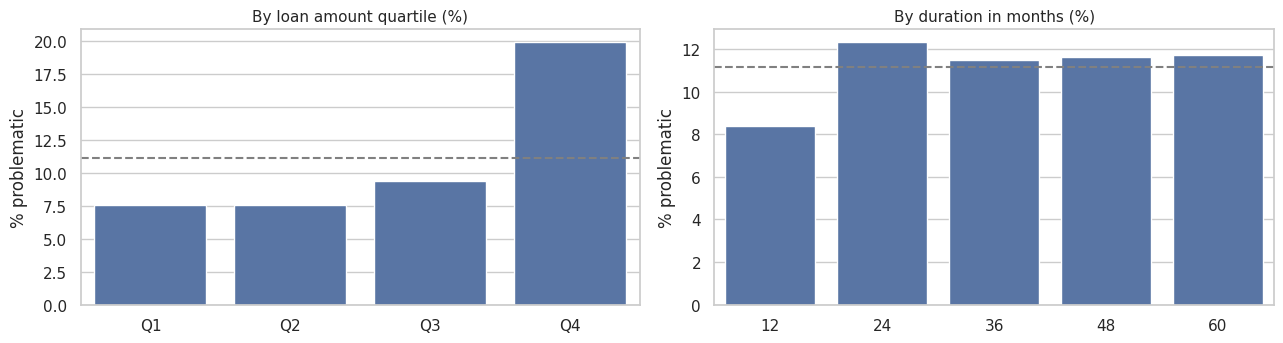


Median loan amount | healthy: 110,436 | problematic: 188,460


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
print(plot_rate('amount_q', ax[0], 'By loan amount quartile (%)'))
print(rate_by('duration'))
plot_rate('duration', ax[1], 'By duration in months (%)')
plt.tight_layout(); plt.show()

print('\nMedian loan amount | healthy:', f"{master.loc[master.is_problem==0,'loan_amount'].median():,.0f}",
      '| problematic:', f"{master.loc[master.is_problem==1,'loan_amount'].median():,.0f}")

**Output.** Rate by loan amount quartile: 7.6%, 7.6%, 9.4%, 19.9%. Duration is nearly flat. Median problematic loan 188,460 against 110,436 for healthy ones.

**Insight.** Risk sits in large principal, not long tenor, and it is a threshold rather than a gradient. Duration only matters through the instalment it produces, which Q3 tests.

### 3.3 Repayment burden (root cause: loan burden and cash flow strain)
Focus: affordability, the instalment measured against what the customer actually earns and spends.
Variables: the three Milestone 1 ratios, `payment_to_income` (instalment ÷ district salary), `payment_to_inflow` (instalment ÷ own monthly inflow), `outflow_to_inflow` (money out ÷ money in, pre-loan). Method: quartile comparison and correlation.

Payment ÷ district salary
       loans  problems  rate
pti_q                       
Q1       171         8   4.7
Q2       170        13   7.6
Q3       170        24  14.1
Q4       171        31  18.1 

Payment ÷ own monthly inflow
        loans  problems  rate
ptif_q                       
Q1        171        10   5.8
Q2        170        18  10.6
Q3        170        15   8.8
Q4        171        33  19.3 

Outflow ÷ inflow
       loans  problems  rate
oti_q                       
Q1       170        15   8.8
Q2       170        11   6.5
Q3       169        15   8.9
Q4       170        32  18.8 



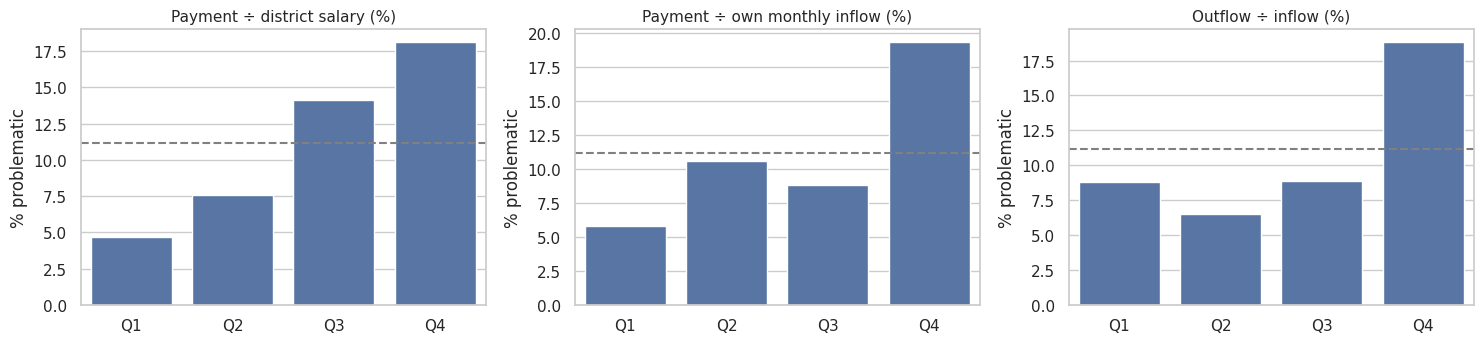

payment_to_income    0.184
payment_to_inflow    0.259
outflow_to_inflow    0.040
Name: is_problem, dtype: float64


In [11]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
for a, (q, t) in zip(ax, [('pti_q', 'Payment ÷ district salary'),
                          ('ptif_q', 'Payment ÷ own monthly inflow'),
                          ('oti_q', 'Outflow ÷ inflow')]):
    print(t); print(plot_rate(q, a, t + ' (%)'), '\n')
plt.tight_layout(); plt.show()

print(master[['payment_to_income', 'payment_to_inflow', 'outflow_to_inflow', 'is_problem']]
      .corr()['is_problem'].drop('is_problem').round(3))

**Output.** Each ratio climbs into its top quartile: 4.7% to 18.1% for payment-to-income, 5.8% to 19.3% for payment-to-inflow, 8.8% to 18.8% for outflow-to-inflow. Correlation with `is_problem`: 0.26, 0.18 and 0.04 respectively.

**Insight.** Affordability beats loan size, and the customer's own inflow is the better denominator, since the district salary is only a proxy. `outflow_to_inflow` scores low because it is skewed and separates only at the extreme. All three inputs exist at application time.

### 3.4 Pre-loan account liquidity (root cause: weak account liquidity)
Focus: the cushion the account carries before the loan is granted.
Variables: `avg_balance`, `min_balance`, `ever_negative`. Method: quartile comparison, medians, binary flag.

           loans  problems  rate
balance_q                       
Q1           171        33  19.3
Q2           170        14   8.2
Q3           170        20  11.8
Q4           171         9   5.3


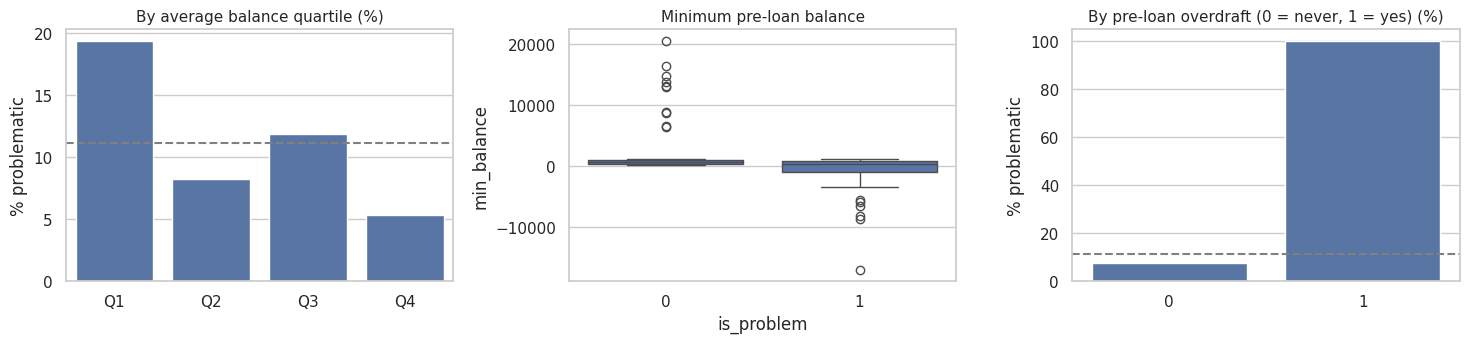

               loans  problems   rate
ever_negative                        
0                655        49    7.5
1                 27        27  100.0

Medians:
            avg_balance  min_balance
is_problem                          
0               44113.0        700.0
1               37002.0        390.0

Share of all problematic loans caught by the overdraft flag: 35.5%


In [12]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
print(plot_rate('balance_q', ax[0], 'By average balance quartile (%)'))
sns.boxplot(data=master, x='is_problem', y='min_balance', ax=ax[1]); ax[1].set_title('Minimum pre-loan balance', fontsize=11)
r = plot_rate('ever_negative', ax[2], 'By pre-loan overdraft (0 = never, 1 = yes) (%)')
plt.tight_layout(); plt.show()

print(r)
print('\nMedians:'); print(master.groupby('is_problem')[['avg_balance', 'min_balance']].median().round(0))
print('\nShare of all problematic loans caught by the overdraft flag:',
      f"{master.query('ever_negative == 1')['is_problem'].sum() / master['is_problem'].sum():.1%}")

**Output.** Lowest average balance quartile fails at 19.3% against 5.3% in the highest. Median minimum balance is 700 for healthy loans and 390 for problematic ones. All 27 accounts that went negative before applying failed, against 7.5% for the rest, and that one flag covers 35.5% of bad loans.

**Insight.** The trough matters more than the average, since a customer can hold a comfortable mean balance and still hit zero before payday. Caveat: 27 loans is small, so 100% will not hold on new data. Use it as a manual review screen, not a scorecard.

**Next.** Behaviour clearly separates risk, so section 3.5 tests whether relationship depth or demographics add anything on top.

### 3.5 Banking history and customer profile (root cause: thin banking history)
Focus: the remaining candidates, relationship depth and demographics, tested last so a weak result is read against everything already established.
Variables: `tenure_days`, `n_trx`, `gender`, `age_at_loan`, `unemp_96`. Method: quartile comparison and correlation.

          loans  problems  rate
tenure_q                       
Q1          171        26  15.2
Q2          170        18  10.6
Q3          170        17  10.0
Q4          171        15   8.8
        loans  problems  rate
gender                       
female    348        41  11.8
male      334        35  10.5
          loans  problems  rate
age_band                       
18-30       193        21  10.9
31-40       168        20  11.9
41-50       148        15  10.1
51-60       140        16  11.4
60+          16         2  12.5


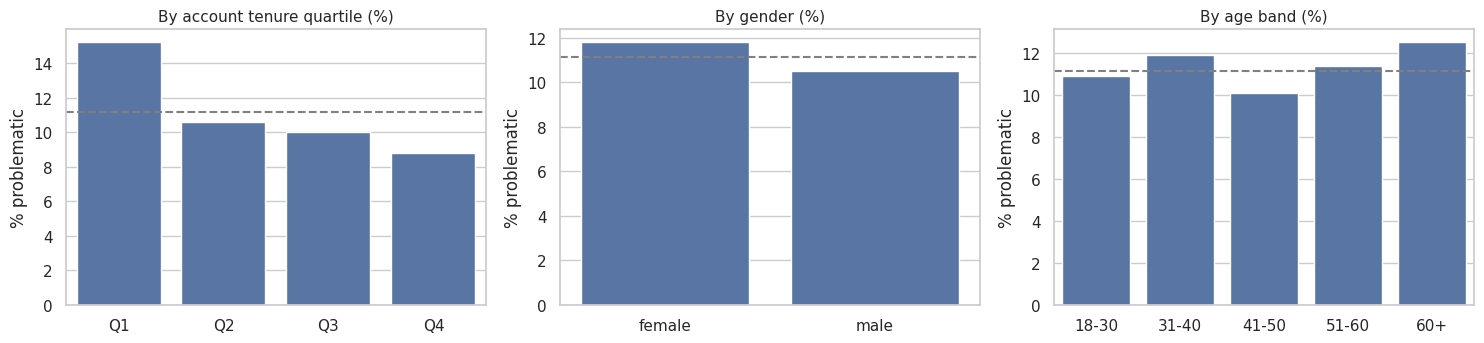

min_balance         -0.261
avg_balance         -0.160
n_trx               -0.079
tenure_days         -0.075
age_at_loan         -0.003
unemp_96             0.018
duration             0.026
loan_amount          0.168
payment_to_income    0.184
payment_to_inflow    0.259
Name: is_problem, dtype: float64


In [13]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
print(plot_rate('tenure_q', ax[0], 'By account tenure quartile (%)'))
print(plot_rate('gender', ax[1], 'By gender (%)'))
master['age_band'] = pd.cut(master['age_at_loan'], [17, 30, 40, 50, 60, 100],
                            labels=['18-30', '31-40', '41-50', '51-60', '60+'])
print(plot_rate('age_band', ax[2], 'By age band (%)'))
plt.tight_layout(); plt.show()

cols = ['is_problem', 'min_balance', 'avg_balance', 'n_trx', 'tenure_days', 'age_at_loan',
        'unemp_96', 'duration', 'loan_amount', 'payment_to_income', 'payment_to_inflow']
print(master[cols].corr()['is_problem'].drop('is_problem').sort_values().round(3))

**Output.** Tenure moves from 15.2% in the newest quartile to 8.8% in the longest, a 1.7× effect. Gender differs by about one point, age bands move without direction, and district unemployment correlates at 0.018.

**Insight.** Risk here is behavioural, not demographic or geographic. The bank lends only to existing account holders, so it already holds direct evidence that dominates any proxy, and behavioural scoring avoids fair lending exposure.

---
## Step 4 — High-value insights

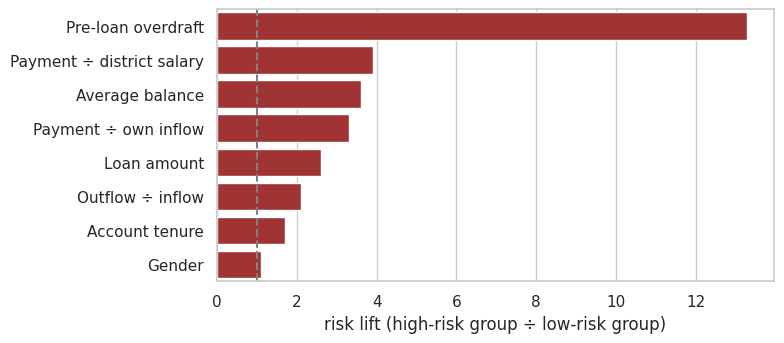

,driver,low_risk_%,high_risk_%,lift
0,Pre-loan overdraft,7.5,100.0,13.3
1,Payment ÷ district salary,4.7,18.1,3.9
2,Average balance,5.3,19.3,3.6
3,Payment ÷ own inflow,5.8,19.3,3.3
4,Loan amount,7.6,19.9,2.6
5,Outflow ÷ inflow,8.8,18.8,2.1
6,Account tenure,8.8,15.2,1.7
7,Gender,10.5,11.8,1.1


In [14]:
def contrast(col, low, high, label):
    r = rate_by(col)
    return {'driver': label, 'low_risk_%': r.loc[low, 'rate'], 'high_risk_%': r.loc[high, 'rate']}

summary = pd.DataFrame([
    contrast('ever_negative', 0, 1, 'Pre-loan overdraft'),
    contrast('ptif_q', 'Q1', 'Q4', 'Payment ÷ own inflow'),
    contrast('pti_q', 'Q1', 'Q4', 'Payment ÷ district salary'),
    contrast('balance_q', 'Q4', 'Q1', 'Average balance'),
    contrast('oti_q', 'Q1', 'Q4', 'Outflow ÷ inflow'),
    contrast('amount_q', 'Q1', 'Q4', 'Loan amount'),
    contrast('tenure_q', 'Q4', 'Q1', 'Account tenure'),
    contrast('gender', 'male', 'female', 'Gender'),
])
summary['lift'] = (summary['high_risk_%'] / summary['low_risk_%']).round(1)
summary = summary.sort_values('lift', ascending=False)

fig, ax = plt.subplots(figsize=(8, 3.6))
sns.barplot(data=summary, y='driver', x='lift', ax=ax, color='firebrick')
ax.axvline(1, ls='--', color='grey'); ax.set_xlabel('risk lift (high-risk group ÷ low-risk group)'); ax.set_ylabel('')
plt.tight_layout(); plt.show()
summary.reset_index(drop=True)

**1. A pre-loan overdraft is a warning the bank throws away.** All 27 such accounts failed, covering 35.5% of bad loans. One screen removes 27 of 76 bad loans while touching 4% of applicants.

**2. Affordability is the cleanest gradient.** Payment-to-inflow rises 5.8% to 19.3% and correlates at 0.26, while loan amount does nothing until its top quartile. Underwrite on the instalment, not the principal.

**3. Risk is behavioural, not demographic.** Balance behaviour separates the groups, gender and age do not.

**4. The 1998 improvement is an illusion.** Those loans had months, not years, to deteriorate, so cohorts must be compared at equal age.

---
## Step 5 — Business alignment

| Milestone 1 root cause | Metric promised in M1 | Verdict |
|---|---|---|
| Weak account liquidity | avg balance before the loan | **Confirmed, strongest** — 100% failure after an overdraft, min balance correlates −0.26 |
| Cash flow strain | outflow ÷ inflow | **Confirmed at the extreme** — 8.8% → 18.8%, weak overall (0.04) |
| Loan burden | payments ÷ monthly inflow | **Confirmed** — 5.8% → 19.3%, strongest positive correlate at 0.26 |
| Thin banking history | count of pre-loan transactions | **Weak** — 15.2% vs 8.8%, secondary effect |

Every variable above is available **before disbursement**, because the transaction aggregates were restricted to dates earlier than the loan date. That is what makes them underwriting rules rather than post mortems.

**Recommendations**
1. Send any applicant with a negative balance in the last twelve months to manual review.
2. Cap payment-to-inflow at underwriting, so the instalment governs the decision.
3. Add `min_balance`, `avg_balance` and `ever_negative` to the scorecard.
4. Report the KPI by vintage at equal age, never as one portfolio number.

**Limitations.** 682 loans and only 76 events, so the 27 account finding needs revalidation on a larger sample. Individual income is absent, so `payment_to_income` uses a district proxy. These are associations, not causal estimates. Milestone 3 fits and validates a model on the exported table.

In [15]:
cols = ['loan_id','account_id','loan_date','loan_year','loan_amount','duration','payments','status',
        'is_problem','gender','age_at_loan','district_name','avg_salary','unemp_96','tenure_days','n_trx',
        'avg_balance','min_balance','n_negative_balance','ever_negative','payment_to_income',
        'payment_to_inflow','outflow_to_inflow']
master[cols].to_csv('loan_master_clean.csv', index=False)
print('exported loan_master_clean.csv', master[cols].shape)

exported loan_master_clean.csv (682, 23)


---
---
# Milestone 3 : Visualization & Insights
**CRISP-DM phase:** Evaluation. This part continues from the Milestone 2 `master` table. Nothing above is changed: Milestone 3 works on a copy called `df`.

| Step | What it does | Output |
|---|---|---|
| 1 | Prepare a copy of the data | `df` |
| 2 | Draw 8 charts, each titled with its insight | PNG files for the deck |
| 3 | Check the drivers with a simple model | risk score, AUC |
| 4 | Test each recommendation against the 5% target | impact table |
| 5 | Summarise finding -> insight -> action | summary table |
| 6 | Export files for Tableau and the deck | CSV + ZIP |

## M3 Step 1 : Prepare the data

In [ ]:
import os, shutil
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve

# 1. Work on a copy, so the Milestone 2 table stays exactly the same
df = master.copy()

# 2. A ratio divided by zero becomes infinity, treat it as missing
for col in ['payment_to_inflow', 'payment_to_income', 'outflow_to_inflow']:
    df[col] = df[col].replace([np.inf, -np.inf], np.nan)

# 3. Split each numeric driver into 4 equal groups (Q1 lowest, Q4 highest)
quartile_columns = {
    'payment_to_income': 'pti_q',
    'payment_to_inflow': 'ptif_q',
    'outflow_to_inflow': 'oti_q',
    'loan_amount':       'amount_q',
    'avg_balance':       'balance_q',
    'tenure_days':       'tenure_q',
}
for col, new_col in quartile_columns.items():
    df[new_col] = pd.qcut(df[col], 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

# 4. Readable labels for charts and Tableau
df['age_band'] = pd.cut(df['age_at_loan'], bins=[17, 30, 40, 50, 60, 100],
                        labels=['18-30', '31-40', '41-50', '51-60', '60+'])
df['overdraft_label'] = df['ever_negative'].map({0: 'Never overdrawn', 1: 'Overdrawn before loan'})
df['status_label'] = df['status'].map({'A': 'A finished, paid',   'B': 'B finished, unpaid',
                                       'C': 'C running, ok',      'D': 'D running, in debt'})

# 5. Key numbers used everywhere
TOTAL_LOANS = len(df)
BAD_LOANS   = int(df['is_problem'].sum())
RATE        = df['is_problem'].mean() * 100     # current problematic rate in %
TARGET      = 5                                 # target from Milestone 1 in %

# 6. Colours: red = risk group, grey = others, green = target
RED, GREY, GREEN = '#C0392B', '#C8CDD2', '#1E8449'
os.makedirs('m3_charts', exist_ok=True)

print('Loans:', TOTAL_LOANS, '| problematic:', BAD_LOANS, f'| rate: {RATE:.1f}%', f'| target: {TARGET}%')

### Helper functions
Three small functions so every chart looks the same.
`rate_by(col, df)` is the Milestone 2 function, reused as it is, applied to the copy.

In [ ]:
def draw_bar(ax, col, red_groups, title):
    # problematic rate per group, same function as Milestone 2
    table = rate_by(col, df)

    # red for the risk group, grey for the rest
    colors = []
    for group in table.index:
        if str(group) in red_groups:
            colors.append(RED)
        else:
            colors.append(GREY)

    ax.bar(table.index.astype(str), table['rate'], color=colors)
    ax.bar_label(ax.containers[0], fmt='%.1f%%', fontweight='bold')       # number on each bar
    ax.axhline(RATE, ls='--', color='grey', label=f'portfolio {RATE:.1f}%')  # baseline line
    ax.set_title(title, loc='left', fontweight='bold')
    ax.set_ylabel('% problematic loans')
    ax.legend(frameon=False)
    return table


def save_chart(fig, name):
    fig.tight_layout()
    fig.savefig(f'm3_charts/{name}.png', dpi=200, bbox_inches='tight')
    plt.show()

## M3 Step 2 : Visualization

| # | Analysis | Chart | Why |
|---|---|---|---|
| 1 | KPI size | scorecard | four numbers in one glance |
| 2 | Trend by year | line | shows direction over time |
| 3 | Pre-loan overdraft | bar | compares two groups |
| 4 | Affordability vs loan size | bar | gradient vs threshold side by side |
| 5 | Liquidity | bar + boxplot | rate per group and spread of balance |
| 6 | Demographics | bar | shows there is no effect |
| 7 | Driver ranking | horizontal bar | ranking |
| 8 | Correlation | heatmap | many variables at once |

### Chart 1 : KPI scorecard

In [ ]:
bad_principal = df.loc[df['is_problem'] == 1, 'loan_amount'].sum()

kpis = [
    (f'{TOTAL_LOANS:,}',                 'loans analysed',            'black'),
    (f'{BAD_LOANS}',                     'problematic loans (B + D)', 'black'),
    (f'{RATE:.1f}%',                     'problematic rate',          RED),
    (f'CZK {bad_principal/1e6:.1f}M',    'principal at risk',         RED),
]

fig, axes = plt.subplots(1, 4, figsize=(14, 2.2))
for ax, (value, label, color) in zip(axes, kpis):
    ax.axis('off')
    ax.text(0.5, 0.6, value, ha='center', fontsize=24, fontweight='bold', color=color)
    ax.text(0.5, 0.2, label, ha='center', color='grey')

fig.suptitle(f'1 in {round(100 / RATE)} loans goes bad, more than twice the {TARGET}% target',
             x=0.01, ha='left', fontweight='bold')
save_chart(fig, '01_kpi_scorecard')

### Chart 2 : Trend by origination year

In [ ]:
by_year   = rate_by('loan_year', df)
last_year = by_year.index.max()
old_years = by_year['rate'][:-1]          # every year except the last one

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(by_year.index, by_year['rate'], marker='o', color='#2C3E50', lw=2.5)

# write the value above each point
for year, value in by_year['rate'].items():
    ax.annotate(f'{value}%', (year, value), textcoords='offset points', xytext=(0, 8), ha='center', fontweight='bold')

ax.axhline(RATE, ls='--', color='grey', label='portfolio')
ax.axhline(TARGET, ls=':', color=GREEN, label=f'target {TARGET}%')

# shade the last year: loans had too little time to go bad
ax.axvspan(last_year - 0.4, last_year + 0.4, color=RED, alpha=0.1)
ax.text(last_year, 1, 'maturity bias:\nunder 12 months\nto fail', color=RED, ha='center', fontsize=9)

ax.set_title(f'The true rate is {old_years.min():.0f} to {old_years.max():.0f}%, '
             f'the {last_year} drop is not an improvement', loc='left', fontweight='bold')
ax.set_ylabel('% problematic loans')
ax.legend(frameon=False)
save_chart(fig, '02_trend_by_vintage')
by_year

### Chart 3 : Pre-loan overdraft

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
overdraft = draw_bar(ax, 'overdraft_label', ['Overdrawn before loan'], '')

overdraft_rate  = overdraft.loc['Overdrawn before loan', 'rate']
overdraft_cover = overdraft.loc['Overdrawn before loan', 'problems'] / BAD_LOANS * 100   # share of all bad loans

ax.set_title(f'{overdraft_rate:.0f}% of borrowers who overdrew before applying went bad '
             f'({overdraft_cover:.1f}% of all bad loans)', loc='left', fontweight='bold')
save_chart(fig, '03_overdraft_flag')
overdraft

### Chart 4 : Affordability vs loan size

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2), sharey=True)
by_inflow = draw_bar(ax[0], 'ptif_q',   ['Q4'], 'Instalment ÷ own inflow: steady climb')
by_amount = draw_bar(ax[1], 'amount_q', ['Q4'], 'Loan amount: flat until the top quartile')

first, last = by_inflow['rate'].iloc[0], by_inflow['rate'].iloc[-1]
fig.suptitle(f'Risk rises with the instalment ({first:.1f}% -> {last:.1f}%), not with the loan size',
             x=0.01, ha='left', fontweight='bold', fontsize=13)
save_chart(fig, '04_affordability_vs_size')

### Chart 5 : Pre-loan liquidity

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))

# left: problematic rate per average balance quartile
by_balance = draw_bar(ax[0], 'balance_q', ['Q1'], 'Lowest average balance quartile fails most')

# right: minimum balance of healthy vs problematic loans
sns.boxplot(data=df, x='is_problem', y='min_balance', palette=[GREY, RED], showfliers=False, ax=ax[1])
ax[1].set_xticklabels(['Healthy', 'Problematic'])
ax[1].set_xlabel('')
ax[1].set_title('Bad loans come from accounts that run near zero', loc='left', fontweight='bold')

save_chart(fig, '05_liquidity')
df.groupby('is_problem')[['avg_balance', 'min_balance']].median().round(0)

### Chart 6 : Demographics vs behaviour

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
draw_bar(ax[0], 'gender',   [],     'Gender: no gap')
draw_bar(ax[1], 'age_band', [],     'Age: no direction')
draw_bar(ax[2], 'tenure_q', ['Q1'], 'Tenure: secondary effect')

fig.suptitle('Who the customer is barely moves risk, how the account behaves does',
             x=0.01, ha='left', fontweight='bold', fontsize=13)
save_chart(fig, '06_demographics')

### Chart 7 : Driver ranking
**Risk lift** = rate in the high-risk group ÷ rate in the low-risk group. A lift of 3x means three times more bad loans.

In [ ]:
# (column, low-risk group, high-risk group, name on the chart)
drivers = [
    ('ever_negative', 0,      1,        'Pre-loan overdraft'),
    ('ptif_q',        'Q1',   'Q4',     'Payment ÷ own inflow'),
    ('pti_q',         'Q1',   'Q4',     'Payment ÷ district salary'),
    ('balance_q',     'Q4',   'Q1',     'Low average balance'),
    ('oti_q',         'Q1',   'Q4',     'Outflow ÷ inflow'),
    ('amount_q',      'Q1',   'Q4',     'Loan amount'),
    ('tenure_q',      'Q4',   'Q1',     'Short account tenure'),
    ('gender',        'male', 'female', 'Gender'),
]

rows = []
for col, low, high, name in drivers:
    table = rate_by(col, df)
    lift  = table.loc[high, 'rate'] / table.loc[low, 'rate']
    rows.append({'driver': name, 'lift': lift})

lift_table = pd.DataFrame(rows).sort_values('lift')

fig, ax = plt.subplots(figsize=(9, 4.2))
colors = [GREY] * (len(lift_table) - 3) + [RED] * 3        # top 3 in red
ax.barh(lift_table['driver'], lift_table['lift'], color=colors)
ax.bar_label(ax.containers[0], fmt='%.1fx', fontweight='bold')
ax.axvline(1, ls='--', color='grey')
ax.set_xlabel('risk lift = high-risk group rate ÷ low-risk group rate')
ax.set_title('Three behavioural signals lead the ranking', loc='left', fontweight='bold')
save_chart(fig, '07_driver_ranking')

### Chart 8 : Correlation heatmap

In [ ]:
heatmap_columns = ['is_problem', 'payment_to_inflow', 'payment_to_income', 'min_balance', 'avg_balance',
                   'ever_negative', 'loan_amount', 'duration', 'tenure_days', 'n_trx', 'age_at_loan', 'unemp_96']
corr = df[heatmap_columns].corr()
upper_half = np.triu(np.ones_like(corr, dtype=bool), k=1)     # hide the repeated half

fig, ax = plt.subplots(figsize=(10, 7.5))
sns.heatmap(corr, mask=upper_half, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Behaviour and affordability correlate with bad loans, demographics do not',
             loc='left', fontweight='bold')
save_chart(fig, '08_correlation_heatmap')

## M3 Step 3 : Model validation
A simple logistic regression checks that the drivers still separate good and bad loans when used together.
Each loan is scored by a model that never saw it (5-fold cross validation).
**AUC** = 0.5 means guessing, 1.0 means perfect.

In [ ]:
features = ['payment_to_inflow', 'min_balance', 'avg_balance', 'ever_negative',
            'loan_amount', 'tenure_days', 'n_trx', 'outflow_to_inflow']
X = df[features]
y = df['is_problem']

# fill missing -> put on the same scale -> logistic regression
model = make_pipeline(SimpleImputer(strategy='median'),
                      StandardScaler(),
                      LogisticRegression(class_weight='balanced', max_iter=2000))

# risk score for every loan, out of sample
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
df['risk_score'] = cross_val_predict(model, X, y, cv=folds, method='predict_proba')[:, 1]
auc = roc_auc_score(y, df['risk_score'])

# how many bad loans sit in the riskiest 20% of applicants
top20   = df['risk_score'] >= df['risk_score'].quantile(0.8)
capture = df.loc[top20, 'is_problem'].sum() / BAD_LOANS * 100

# which features push the score up
model.fit(X, y)
coef = pd.Series(model[-1].coef_[0], index=features).sort_values()

fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
fpr, tpr, _ = roc_curve(y, df['risk_score'])
ax[0].plot(fpr, tpr, color=RED, label=f'model AUC {auc:.2f}')
ax[0].plot([0, 1], [0, 1], '--', color='grey', label='random 0.50')
ax[0].set_title(f'The drivers separate risk out of sample (AUC {auc:.2f})', loc='left', fontweight='bold')
ax[0].legend()

coef_colors = [RED if value > 0 else GREY for value in coef]
ax[1].barh(coef.index, coef.values, color=coef_colors)
ax[1].set_title('What pushes the risk score up', loc='left', fontweight='bold')
save_chart(fig, '09_model_validation')

print(f'AUC {auc:.3f} | riskiest 20% of applicants hold {capture:.1f}% of bad loans')

## M3 Step 4 : Business impact simulation
Each recommendation works as a screen before approval.
Assumption: a flagged application is declined or restructured, so it leaves the portfolio.

In [ ]:
# the three screens
cutoff          = df['payment_to_inflow'].quantile(0.75)     # start of the top quartile
flag_overdraft  = df['ever_negative'] == 1
flag_afford     = df['payment_to_inflow'] > cutoff
flag_model      = top20
flag_nothing    = pd.Series(False, index=df.index)

scenarios = {
    'Current portfolio':               flag_nothing,
    'R1 Overdraft -> manual review':   flag_overdraft,
    f'R2 Payment ÷ inflow > {cutoff:.2f}': flag_afford,
    'R1 + R2':                         flag_overdraft | flag_afford,
    'R3 Model score top 20%':          flag_model,
    'R1 + R3':                         flag_overdraft | flag_model,
}

def simulate(name, flagged):
    removed = df[flagged]          # loans the screen stops
    kept    = df[~flagged]         # loans that stay in the portfolio
    return {
        'scenario':                    name,
        'flagged_loans':               int(flagged.sum()),
        'flagged_%':                   round(flagged.mean() * 100, 1),
        'bad_avoided':                 int(removed['is_problem'].sum()),
        'good_turned_away':            int((removed['is_problem'] == 0).sum()),
        'bad_principal_avoided_CZK_M': round(removed.loc[removed['is_problem'] == 1, 'loan_amount'].sum() / 1e6, 1),
        'rate_after_%':                round(kept['is_problem'].mean() * 100, 1),
    }

rows = []
for name, flagged in scenarios.items():
    rows.append(simulate(name, flagged))
impact = pd.DataFrame(rows)
impact['meets_target'] = impact['rate_after_%'] < TARGET

# chart: grey = today, green = below target, red = still above
colors = []
for i, row in impact.iterrows():
    if i == 0:
        colors.append(GREY)
    elif row['meets_target']:
        colors.append(GREEN)
    else:
        colors.append(RED)

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.barh(impact['scenario'][::-1], impact['rate_after_%'][::-1], color=colors[::-1])
ax.bar_label(ax.containers[0], fmt='%.1f%%', fontweight='bold')
ax.axvline(TARGET, ls=':', color=GREEN, lw=2)
ax.set_title('Problematic rate left after each screen (green = below the 5% target)', loc='left', fontweight='bold')
save_chart(fig, '10_impact_simulation')
impact

## M3 Step 5 : Finding -> insight -> alignment -> recommendation

In [ ]:
# numbers used in the sentences
rate_after = impact.set_index('scenario')['rate_after_%']
od_loans   = overdraft.loc['Overdrawn before loan', 'loans']
inflow_q1, inflow_q4   = by_inflow['rate'].iloc[0],  by_inflow['rate'].iloc[-1]
balance_q1, balance_q4 = by_balance['rate'].iloc[0], by_balance['rate'].iloc[-1]

insight_summary = pd.DataFrame([
    {'finding':            f'{overdraft_rate:.0f}% of the {od_loans} overdraft accounts went bad ({overdraft_cover:.1f}% of bad loans)',
     'insight':            'The strongest warning signal is already in the bank',
     'business alignment': 'Directly lowers the problematic rate',
     'recommendation':     f'Manual review for any overdraft in the last 12 months, rate -> {rate_after.iloc[1]:.1f}%'},

    {'finding':            f'Payment ÷ inflow climbs {inflow_q1:.1f}% -> {inflow_q4:.1f}%',
     'insight':            'Affordability, not loan size, drives default',
     'business alignment': 'Keeps volume while cutting risky instalments',
     'recommendation':     f'Cap payment ÷ inflow at {cutoff:.2f}, with R1 rate -> {rate_after.iloc[3]:.1f}%'},

    {'finding':            f'Lowest balance quartile {balance_q1:.1f}% vs highest {balance_q4:.1f}%, AUC {auc:.2f}',
     'insight':            'Liquidity predicts risk better than demographics',
     'business alignment': 'Fairer, data-based scoring',
     'recommendation':     f'Add balance features to the scorecard, top 20% review catches {capture:.0f}% of bad loans'},

    {'finding':            f'Rate {old_years.min():.0f} to {old_years.max():.0f}% per vintage, last year {by_year["rate"].iloc[-1]:.1f}%',
     'insight':            'The recent improvement is maturity bias',
     'business alignment': 'Avoids false progress toward 5%',
     'recommendation':     'Report the KPI by vintage at equal loan age'},
])
insight_summary

## M3 Step 6 : Export for Tableau and the deck
In Tableau create **Problematic Rate = SUM([is_problem]) / COUNT([loan_id])** and use it in every view.

In [ ]:
# extra columns for Tableau filters
df['rule_overdraft']     = flag_overdraft.astype(int)
df['rule_affordability'] = flag_afford.astype(int)
df['rule_model_top20']   = flag_model.astype(int)
df['risk_band'] = pd.qcut(df['risk_score'], 5, labels=['Very low', 'Low', 'Medium', 'High', 'Very high'])

tableau_columns = [
    'loan_id', 'account_id', 'loan_date', 'loan_year', 'loan_amount', 'duration', 'payments',
    'status', 'status_label', 'is_problem', 'gender', 'age_at_loan', 'age_band',
    'district_name', 'avg_salary', 'unemp_96', 'tenure_days', 'tenure_q', 'n_trx',
    'avg_balance', 'balance_q', 'min_balance', 'ever_negative', 'overdraft_label',
    'payment_to_income', 'pti_q', 'payment_to_inflow', 'ptif_q', 'outflow_to_inflow', 'oti_q', 'amount_q',
    'risk_score', 'risk_band', 'rule_overdraft', 'rule_affordability', 'rule_model_top20',
]

df[tableau_columns].to_csv('loan_master_tableau.csv', index=False)
impact.to_csv('impact_simulation.csv', index=False)
insight_summary.to_csv('insight_summary.csv', index=False)
shutil.make_archive('m3_charts', 'zip', 'm3_charts')      # all charts in one zip

# download to your computer (works in Colab)
try:
    from google.colab import files
    for file in ['loan_master_tableau.csv', 'impact_simulation.csv', 'insight_summary.csv', 'm3_charts.zip']:
        files.download(file)
except ImportError:
    print('Files saved in the working folder')

**Limitations.** 682 loans and 76 events, so the overdraft finding and the model need revalidation on a larger sample. The simulation assumes flagged applications leave the portfolio. These are associations, not causal effects.